## Extract database

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("varunraskar/credit-risk")

print("Path to dataset files:", path)

100%|██████████| 16.5M/16.5M [00:07<00:00, 2.31MB/s]

Extracting files...
Path to dataset files: /Users/miftahhadiyannoor/.cache/kagglehub/datasets/varunraskar/credit-risk/versions/1


## Import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Condig for pandas
pd.set_option('display.max_columns', None)

In [3]:
# Open the dataset files
df_1 = pd.read_excel(path + "/case_study1.xlsx")
df_2 = pd.read_excel(path + "/case_study2.xlsx")

print(f"Dataframe 1 & Dataframe 2 loaded successfully with shapes: {df_1.shape} and {df_2.shape}")

Dataframe 1 & Dataframe 2 loaded successfully with shapes: (51336, 26) and (51336, 62)


In [4]:
df_1.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32


In [5]:
df_2.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [6]:
df_1.isnull().sum()

PROSPECTID              0
Total_TL                0
Tot_Closed_TL           0
Tot_Active_TL           0
Total_TL_opened_L6M     0
Tot_TL_closed_L6M       0
pct_tl_open_L6M         0
pct_tl_closed_L6M       0
pct_active_tl           0
pct_closed_tl           0
Total_TL_opened_L12M    0
Tot_TL_closed_L12M      0
pct_tl_open_L12M        0
pct_tl_closed_L12M      0
Tot_Missed_Pmnt         0
Auto_TL                 0
CC_TL                   0
Consumer_TL             0
Gold_TL                 0
Home_TL                 0
PL_TL                   0
Secured_TL              0
Unsecured_TL            0
Other_TL                0
Age_Oldest_TL           0
Age_Newest_TL           0
dtype: int64

In [7]:
df_2.isnull().sum()

PROSPECTID                      0
time_since_recent_payment       0
time_since_first_deliquency     0
time_since_recent_deliquency    0
num_times_delinquent            0
                               ..
GL_Flag                         0
last_prod_enq2                  0
first_prod_enq2                 0
Credit_Score                    0
Approved_Flag                   0
Length: 62, dtype: int64

In [8]:
print("\nDataframe info for df_1 & df_2")
print(f"Dataframe 1 info:\n{df_1.info()}\n")
print(f"Dataframe 2 info:\n{df_2.info()}\n")


Dataframe info for df_1 & df_2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  

## Merge dataframe

In [9]:
# Merge both dataframe on 'PROSPECTID' column
for i in df_1.columns:
    for j in df_2.columns:
        if i == j:
            print(f"Column '{i}' is present in both dataframes.")

Column 'PROSPECTID' is present in both dataframes.


In [10]:
df = pd.merge(df_1, df_2, on='PROSPECTID', how='inner')
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [11]:
df['Approved_Flag'].value_counts()

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

In [12]:
# Check for missing values in the merged dataframe
print("\nMissing values in the merged dataframe:")
print(df.isnull().sum())


Missing values in the merged dataframe:
PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 87, dtype: int64


In [13]:
numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical = [col for col in categorical if col != 'Approved_Flag']
print(f"Numeric columns: {numeric}")
print(f"Categorical columns: {categorical}")

Numeric columns: ['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'num_times_delinquent', 'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m

## Data visualization

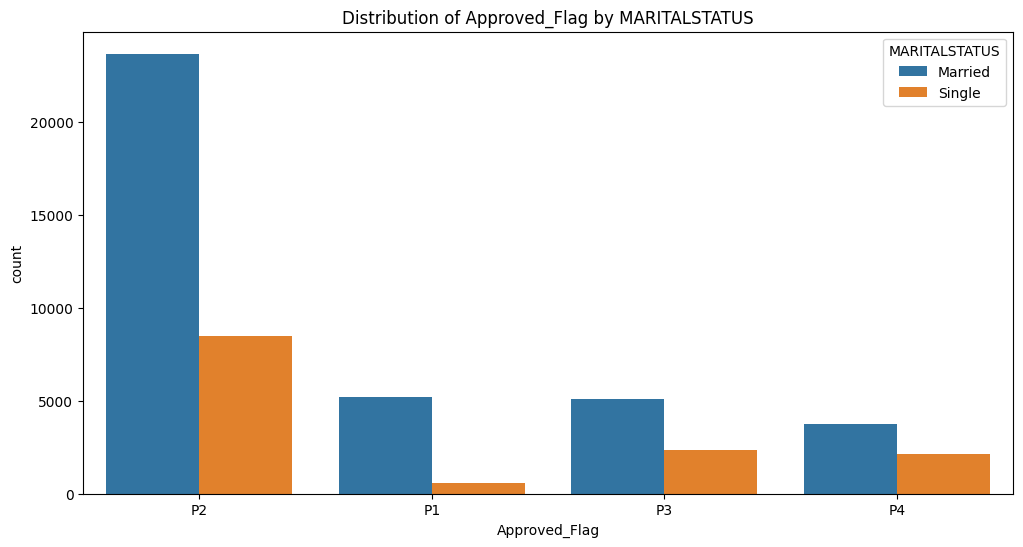

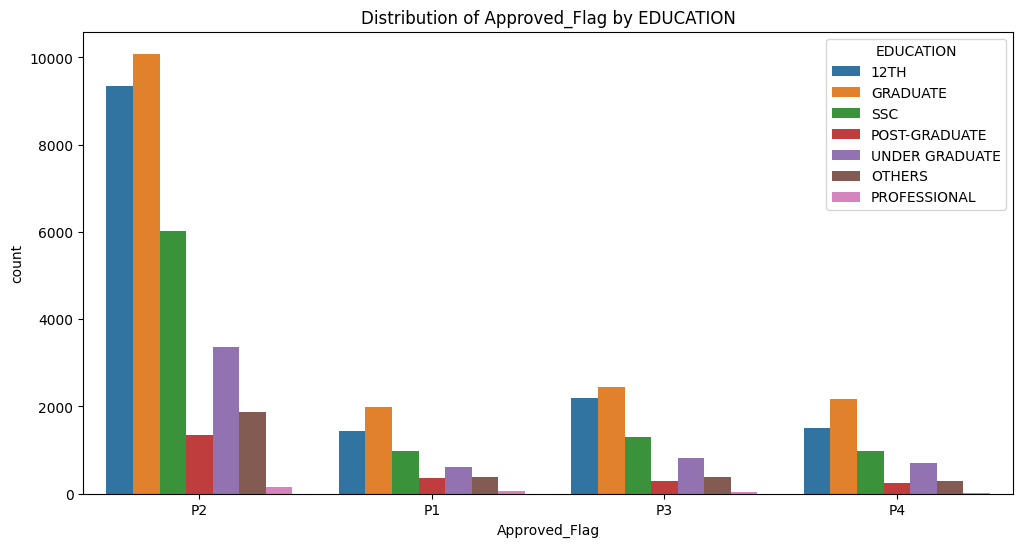

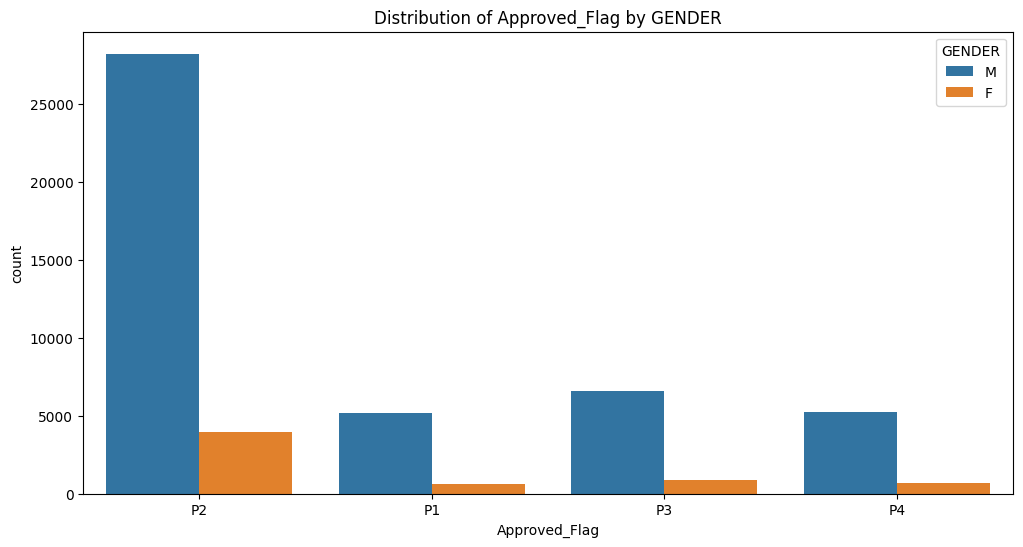

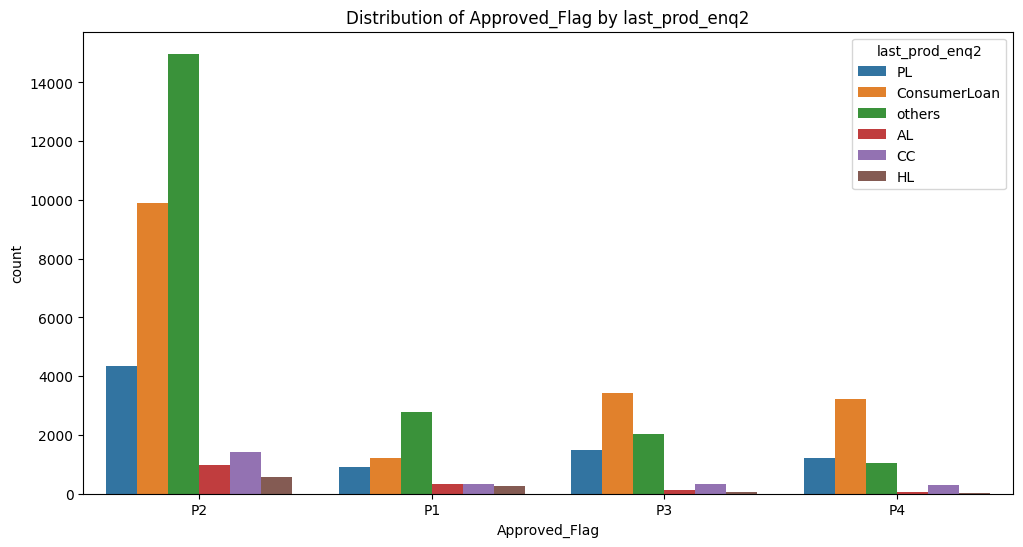

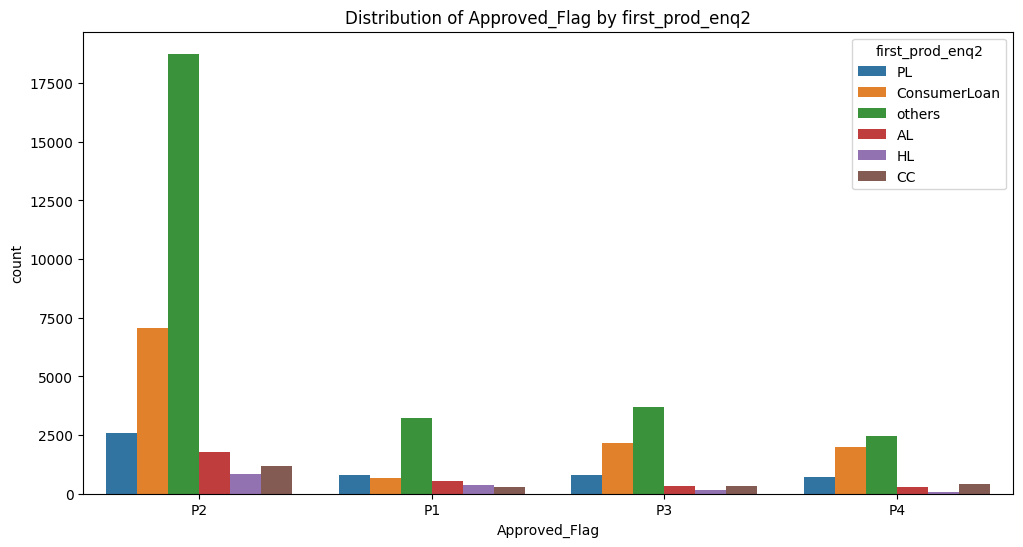

In [14]:
# Visualize for distribution each columns in categorical columns
for col in categorical:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Approved_Flag', hue=col)
    plt.title(f'Distribution of Approved_Flag by {col}')
    plt.legend(title=col, loc='upper right')
    plt.show()

## Flag Scoring based on chi-square results

In [15]:
# Apply Flag scoring for categorical columns
chi2_results = {}
for col in categorical:
    contingency_table = pd.crosstab(df[col], df['Approved_Flag'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results[col] = {'chi2': chi2, 'p-value': p}
    print(f"{col}: Chi2={chi2:2f}, p={p:.2e}")

# Identify significant categorical features (p < 0.05)
significant_categorical = [col for col, result in chi2_results.items() if result['p-value'] < 0.05]
print(f"\nSignificant categorical features (p < 0.05): {significant_categorical}")

MARITALSTATUS: Chi2=1188.129358, p=2.76e-257
EDUCATION: Chi2=225.246136, p=8.46e-38
GENDER: Chi2=19.229726, p=2.45e-04
last_prod_enq2: Chi2=3728.514629, p=0.00e+00
first_prod_enq2: Chi2=1833.116465, p=0.00e+00

Significant categorical features (p < 0.05): ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']


## Encode categorical features

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df.copy()

# Encode categorical features
label_encoders = {}
for col in significant_categorical:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Encode for approved_flag for p1 = 1, p2 = 2, p3 = 3, p4 = 4
df_encoded['Approved_Flag'] = le.fit_transform(df_encoded['Approved_Flag'])

## Numerical Feature Analysis


Top 10 features correlated with target:
Approved_Flag                   1.000000
pct_PL_enq_L6m_of_ever          0.403911
pct_PL_enq_L6m_of_L12m          0.395561
pct_tl_open_L6M                 0.226267
time_since_recent_deliquency    0.219422
time_since_first_deliquency     0.219409
max_delinquency_level           0.219406
pct_tl_open_L12M                0.215037
pct_CC_enq_L6m_of_ever          0.187985
pct_CC_enq_L6m_of_L12m          0.187297
Name: Approved_Flag, dtype: float64


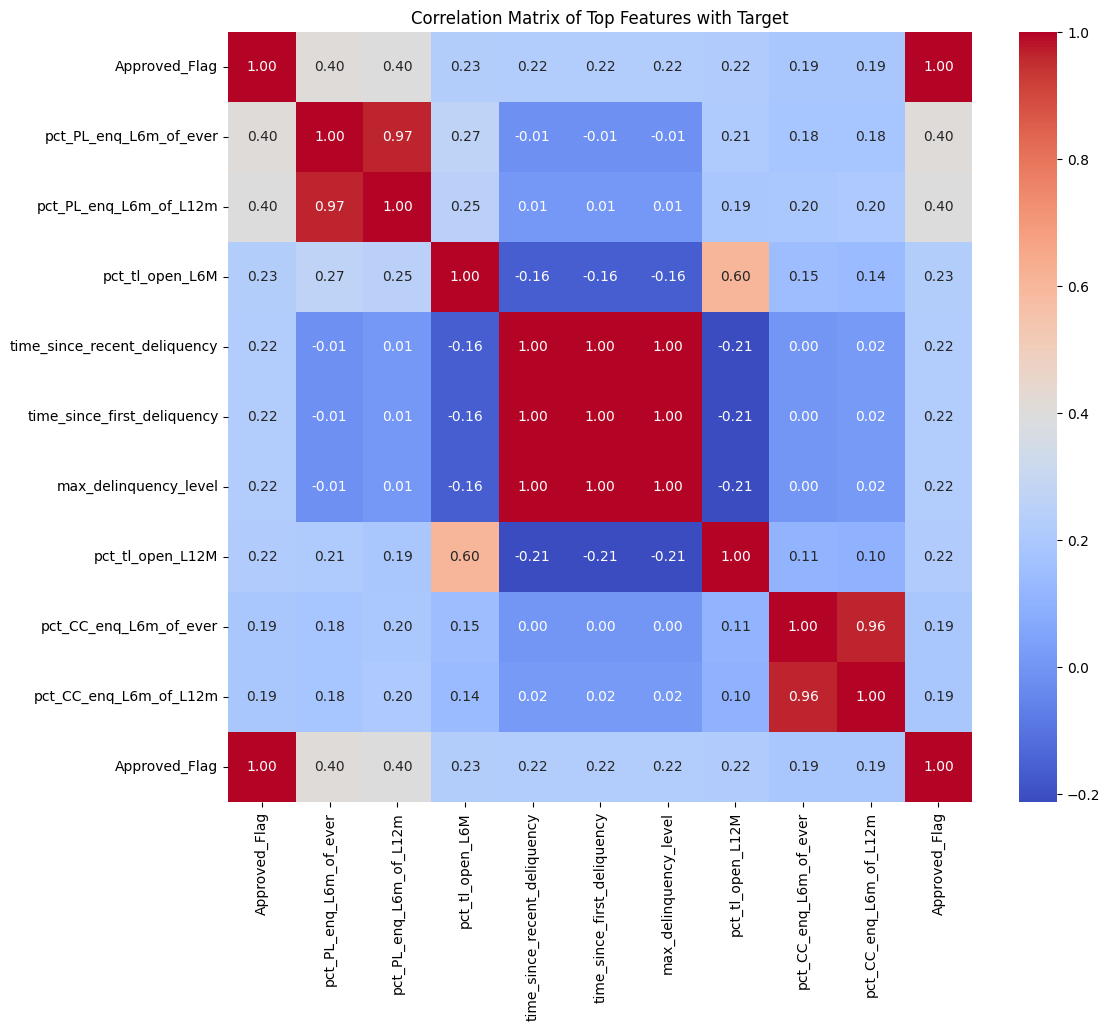

In [17]:
numerical_cols = [col for col in numeric if col not in ['PROSPECTID', 'Approved_Flag']]

# Check correlation with target
correlation_with_target = df_encoded[numerical_cols + ['Approved_Flag']].corr()['Approved_Flag'].sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(correlation_with_target.head(10))

# Visualize correlation matrix for top features
top_features = correlation_with_target.head(10).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[top_features + ['Approved_Flag']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Top Features with Target")
plt.show()

### Check for Multicollinearity (VIF)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a copy of numerical features without highly correlated ones
X_numerical = df_encoded[numerical_cols].copy()

# Handle infinite values
X_numerical = X_numerical.replace([np.inf, -np.inf], np.nan)
X_numerical = X_numerical.fillna(X_numerical.mean())

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_numerical.columns
vif_data['VIF'] = [variance_inflation_factor(X_numerical.values, i) for i in range(X_numerical.shape[1])]

# Sort by VIF and show high multicollinearity
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print("\nFeatures with high VIF (>10) indicate multicollinearity:")
print(vif_data[vif_data['VIF'] > 10])

# Remove highly correlated features (VIF > 10)
features_to_keep = vif_data[vif_data['VIF'] <= 10]['feature'].tolist()
print(f"\nFeatures to keep after removing multicollinearity: {features_to_keep}")


Features with high VIF (>10) indicate multicollinearity:
                         feature           VIF
0                       Total_TL           inf
14                       Auto_TL           inf
32               num_deliq_12mts           inf
31                num_deliq_6mts           inf
22                      Other_TL           inf
21                  Unsecured_TL           inf
20                    Secured_TL           inf
19                         PL_TL           inf
18                       Home_TL           inf
1                  Tot_Closed_TL           inf
16                   Consumer_TL           inf
15                         CC_TL           inf
17                       Gold_TL           inf
33             num_deliq_6_12mts           inf
7                  pct_active_tl           inf
2                  Tot_Active_TL           inf
65        pct_of_active_TLs_ever           inf
54                   CC_enq_L12m  1.320911e+10
53                    CC_enq_L6m  1.150800e+10
56

In [27]:
X_numerical

,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,AGE,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
0,5,4,1,0,0,0.000,0.00,0.200,0.800,0,0,0.000,0.00,0,0,0,0,1,0,4,1,4,0,72,18,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,48,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,696
1,1,0,1,0,0,0.000,0.00,1.000,0.000,1,0,1.000,0.00,0,0,0,1,0,0,0,0,1,0,7,7,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,23,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,685
2,8,0,8,1,0,0.125,0.00,1.000,0.000,2,0,0.250,0.00,1,1,0,6,1,0,0,2,6,0,47,2,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,40,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,693
3,1,0,1,1,0,1.000,0.00,1.000,0.000,1,0,1.000,0.00,1,0,0,0,0,0,0,0,1,1,5,5,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,34,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,673
4,3,2,1,0,0,0.000,0.00,0.333,0.667,0,0,0.000,0.00,0,1,0,0,0,0,0,3,0,2,131,32,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,48,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,3,0,3,1,0,0.333,0.00,1.000,0.000,1,0,0.333,0.00,0,0,0,2,0,0,0,0,3,1,24,5,15,24,23,2,24,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,4,0,0,0,0,0,0,0,3,3,1,43,18500,249,1.000,1.0,0.230,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,1.661,0,0,650
51332,4,2,2,0,1,0.000,0.25,0.500,0.500,2,1,0.500,0.25,0,2,0,2,0,0,0,2,2,0,74,7,57,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,6,4,6,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,203,1,0,0,31,25000,186,0.500,0.0,0.660,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.520,0,0,702
51333,2,1,1,1,1,0.500,0.50,0.500,0.500,2,1,1.000,0.50,0,0,0,2,0,0,0,0,2,0,9,5,32,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,2,2,2,1,5,4,2,28,18000,66,0.500,0.5,0.428,-99999.0,0,-99999.000,0,1.0,0.0,1.0,0.0,0.567,0,0,661
51334,2,1,1,0,0,0.000,0.00,0.500,0.500,1,1,0.500,0.50,0,0,0,2,0,0,0,0,2,0,15,8,58,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,242,1,0,0,25,12802,54,0.500,0.0,0.143,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,1.202,0,0,686


## Handle Outliers

In [19]:
def handle_outliers(df_encoded, columns, method='clip'):
    df_clean = df_encoded.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if method == 'clip':
            df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
            
        elif method == 'remove':
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

# Apply outlier handling on numerical features
df_clean = handle_outliers(df_encoded, numerical_cols, method='clip')

In [20]:
# Find the data which are skewed 
for col in numerical_cols:
    skewness = df_clean[col].skew()
    if abs(skewness) > 1:
        print(f"Column '{col}' is highly skewed with skewness: {skewness:.2f}")

Column 'Total_TL' is highly skewed with skewness: 1.10
Column 'Tot_Closed_TL' is highly skewed with skewness: 1.27
Column 'Tot_Active_TL' is highly skewed with skewness: 1.07
Column 'Total_TL_opened_L6M' is highly skewed with skewness: 1.10
Column 'Tot_TL_closed_L6M' is highly skewed with skewness: 1.83
Column 'pct_tl_open_L6M' is highly skewed with skewness: 1.31
Column 'pct_tl_closed_L6M' is highly skewed with skewness: 1.21
Column 'Total_TL_opened_L12M' is highly skewed with skewness: 1.19
Column 'Tot_TL_closed_L12M' is highly skewed with skewness: 1.18
Column 'pct_tl_closed_L12M' is highly skewed with skewness: 1.34
Column 'Tot_Missed_Pmnt' is highly skewed with skewness: 1.41
Column 'Auto_TL' is highly skewed with skewness: 1.08
Column 'Gold_TL' is highly skewed with skewness: 1.38
Column 'Secured_TL' is highly skewed with skewness: 1.36
Column 'Age_Oldest_TL' is highly skewed with skewness: 1.04
Column 'Age_Newest_TL' is highly skewed with skewness: 1.09
Column 'num_times_delinqu

## Transform skewed features

In [21]:
# Log transformation for skewed features
skewed_features = ['NETMONTHLYINCOME', 'tot_enq', 'max_deliq_6mts', 'time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', ]
for col in skewed_features:
    df_clean[col] = np.log1p(df_clean[col])

## Handle missing value for np NaN

In [22]:
df_clean[['time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'tot_enq']].sample(20)

# Handle missing values with fill mean
time_enquiries = ['time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'tot_enq']
df_clean[time_enquiries] = df_clean[time_enquiries].fillna(df_clean[time_enquiries].mean())

# Handle missing value to fill 0 for max_deliq_6mts
df_clean['max_deliq_6mts'] = df_clean['max_deliq_6mts'].fillna(0)

print("\nMissing values after handling:")
print(df_clean.isnull().sum())


Missing values after handling:
PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 87, dtype: int64


## Prepare dataset for modeling

In [23]:
X_columns = (features_to_keep + significant_categorical + skewed_features)

# Remove any duplicates
X_columns = list(set(X_columns))

# Create features and target variable
X = df_clean[X_columns]
y = df_clean['Approved_Flag']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Feature matrix shape: (51336, 47)
Target distribution:
Approved_Flag
1    0.627221
2    0.145161
3    0.114578
0    0.113040
Name: proportion, dtype: float64


## Default feature X data to original

In [24]:
X_original = df.loc[X.index, X.columns].copy()

print(f"Encoded X shape: {X.shape}")
print(f"Original X shape: {X_original.shape}")
display(X_original.head(2))

Encoded X shape: (51336, 47)
Original X shape: (51336, 47)


,Total_TL_opened_L6M,num_sub_12mts,pct_currentBal_all_TL,num_times_60p_dpd,Tot_Missed_Pmnt,CC_utilization,AGE,Time_With_Curr_Empr,num_dbt_6mts,max_delinquency_level,max_deliq_6mts,max_unsec_exposure_inPct,pct_opened_TLs_L6m_of_L12m,Credit_Score,EDUCATION,num_sub,PL_Flag,last_prod_enq2,time_since_first_deliquency,CC_Flag,pct_tl_closed_L6M,time_since_recent_payment,pct_tl_closed_L12M,num_dbt_12mts,num_std,NETMONTHLYINCOME,num_dbt,recent_level_of_deliq,num_lss,time_since_recent_deliquency,GL_Flag,GENDER,num_lss_6mts,max_recent_level_of_deliq,Tot_TL_closed_L12M,PL_utilization,MARITALSTATUS,pct_tl_open_L12M,tot_enq,HL_Flag,num_times_delinquent,num_lss_12mts,Tot_TL_closed_L6M,num_sub_6mts,max_deliq_12mts,first_prod_enq2,pct_tl_open_L6M
0,0,0,0.798,0,0,-99999.0,48,114,0,29,-99999,13.333,0.0,696,12TH,0,1,PL,35,0,0.0,549,0.0,0,21,51000,0,29,0,15,0,M,0,29,0,0.798,Married,0.0,6,1,11,0,0,0,-99999,PL,0.0
1,0,0,0.370,0,0,-99999.0,23,50,0,-99999,0,0.860,0.0,685,GRADUATE,0,0,ConsumerLoan,-99999,0,0.0,47,0.0,0,0,19000,0,0,0,-99999,0,F,0,0,0,-99999.000,Single,1.0,1,0,0,0,0,0,0,ConsumerLoan,0.0


## Split data into X and y - Scale data features

In [25]:
# Split data into X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature importance
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Data shape after splitting: X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Scaled training feature matrix shape: {X_train_scaled_df.shape}")
print(f"Scaled testing feature matrix shape: {X_test_scaled_df.shape}")

Data shape after splitting: X_train: (41068, 47), X_test: (10268, 47), y_train: (41068,), y_test: (10268,)
Scaled training feature matrix shape: (41068, 47)
Scaled testing feature matrix shape: (10268, 47)


## Training the ML Model

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Define parameters for RandomizedSearchCV
param_dist = {
    'Logistic Regression': {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [1000, 2000]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],    
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

AVERAGING = 'weighted'  # Use weighted averaging for multi-class classification

# Train and evaluate models
results = []
best_models = {}
best_parameters = {}
confusion_matrices = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    random_search = RandomizedSearchCV(model,
                                       param_distributions=param_dist[model_name],
                                       n_iter=10,
                                       scoring=f'f1_{AVERAGING}',
                                       cv=5,
                                       random_state=42,
                                       n_jobs=-1,
                                       verbose=1)

    random_search.fit(X_train_scaled, y_train)

    # Get best model and parameters
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model
    best_parameters[model_name] = random_search.best_params_

    # Predict on test set
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=AVERAGING)
    recall = recall_score(y_test, y_pred, average=AVERAGING)
    f1 = f1_score(y_test, y_pred, average=AVERAGING)

    # Multiclass ROC AUC score
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average=AVERAGING)

    # Store the matrix
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
display(results_df)


Training Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

## Save models

In [ ]:
from pathlib import Path
import json
import joblib

# Save artifacts in credit_risk_production/app
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
models_dir = project_root / 'credit_risk_production' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# Save every tuned model separately
model_paths = {}
for model_name, model in best_models.items():
    model_file = models_dir / f"{model_name.lower().replace(' ', '_').replace('-', '_')}.joblib"
    joblib.dump(model, model_file)
    model_paths[model_name] = model_file.name

# Save the preprocessing objects and all models in one bundle for inference
joblib.dump(
    {
        'models': best_models,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'feature_columns': list(X.columns),
        'class_labels': sorted(y.unique().tolist()),
    },
    models_dir / 'model_bundle.joblib'
)

# Save evaluation metrics and best hyperparameters
results_df.to_csv(models_dir / 'model_metrics.csv', index=False)

with open(models_dir / 'best_parameters.json', 'w') as file:
    json.dump(best_parameters, file, indent=2, default=str)

# Save confusion matrices in a reloadable format
np.savez(
    models_dir / 'confusion_matrices.npz',
    **{name: matrix for name, matrix in confusion_matrices.items()}
)

# Save a small metadata file for the production app
metadata = {
    'model_files': model_paths,
    'metrics_file': 'model_metrics.csv',
    'parameters_file': 'best_parameters.json',
    'confusion_matrices_file': 'confusion_matrices.npz',
    'feature_count': len(X.columns),
    'feature_columns': list(X.columns),
    'class_labels': sorted(y.unique().tolist()),
}

with open(models_dir / 'metadata.json', 'w') as file:
    json.dump(metadata, file, indent=2, default=str)

print(f"Saved model artifacts to: {models_dir}")
print(f"Saved {len(best_models)} tuned models.")
print(sorted(path.name for path in models_dir.iterdir()))

Saved model artifacts to: /Users/miftahhadiyannoor/Documents/credit_risk/credit_risk_production/models
Saved 6 tuned models.
['best_parameters.json', 'confusion_matrices.npz', 'decision_tree.joblib', 'gradient_boosting.joblib', 'k_nearest_neighbors.joblib', 'logistic_regression.joblib', 'metadata.json', 'model_bundle.joblib', 'model_metrics.csv', 'random_forest.joblib', 'xgboost.joblib']


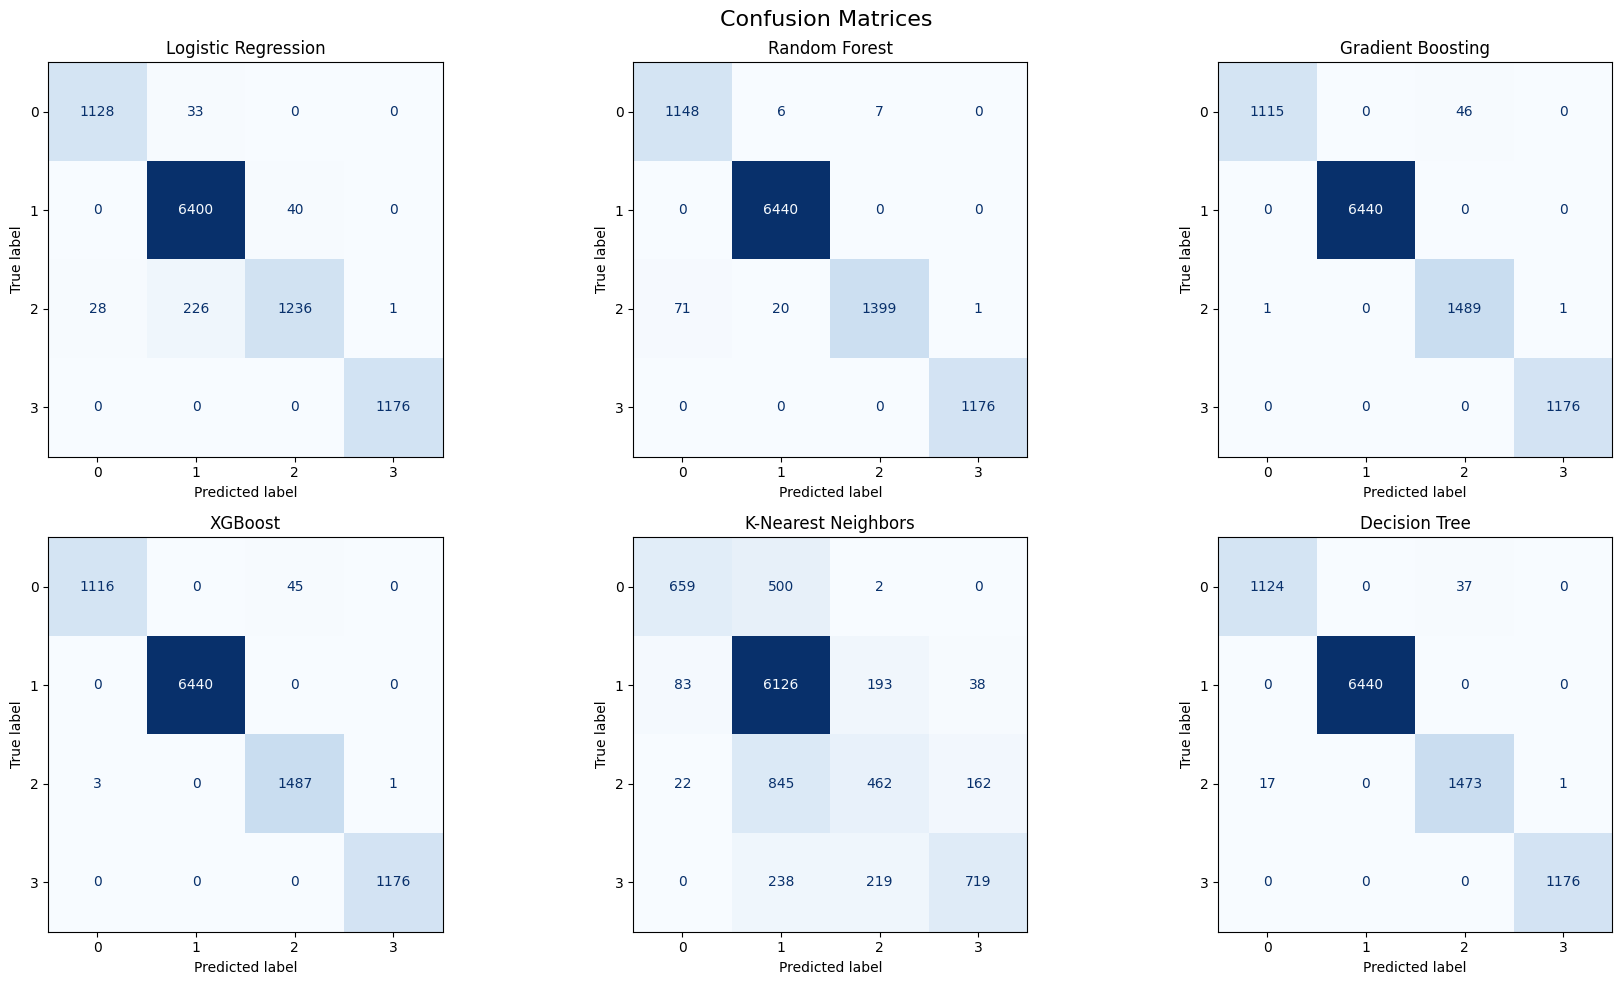

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrices in a 2x2 or 2x3 grid
n_models = len(confusion_matrices)
ncols = 2 if n_models <= 4 else 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(model_name)

# Hide unused axes when the number of models is not exactly 4 or 6
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

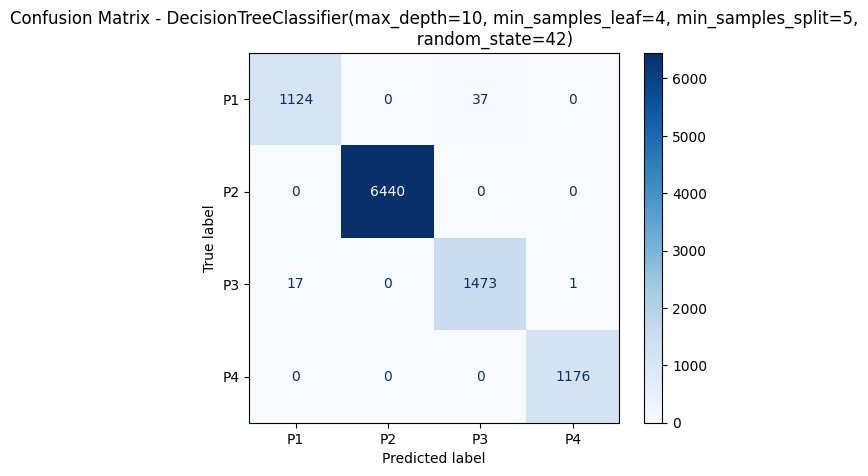

P1 - Precision: 0.985, Recall: 0.968
P2 - Precision: 1.000, Recall: 1.000
P3 - Precision: 0.975, Recall: 0.988
P4 - Precision: 0.999, Recall: 1.000


In [ ]:
# Plot confusion matrix for best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred if 'y_pred_tuned' in locals() else y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['P1', 'P2', 'P3', 'P4'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()

# Calculate class-wise performance
class_names = ['P1', 'P2', 'P3', 'P4']
for i, class_name in enumerate(class_names):
    precision = cm[i,i] / sum(cm[:,i]) if sum(cm[:,i]) > 0 else 0
    recall = cm[i,i] / sum(cm[i,:]) if sum(cm[i,:]) > 0 else 0
    print(f"{class_name} - Precision: {precision:.3f}, Recall: {recall:.3f}")